# MS-TCN++ Pipeline: dall'input alla classificazione

Questo notebook mostra la pipeline completa di inferenza usando il checkpoint migliore del modello **MS-TCN++** (Multi-Stage Temporal Convolutional Network) allenato sul dataset **EGTEA Gaze+** per la segmentazione temporale delle azioni.

**Struttura del notebook:**
1. Setup & configurazione
2. Caricamento delle etichette di classe
3. Architettura del modello
4. Caricamento dei pesi dal checkpoint
5. Caricamento di una clip dal dataset
6. Preprocessing: sliding window
7. Forward pass stage per stage
8. Post-processing e aggregazione delle finestre
9. Visualizzazione finale: GT vs Predizioni

## 0. Setup & configurazione

In [76]:
import sys
import os
from pathlib import Path

# Aggiungi la root del progetto al path
PROJECT_ROOT = Path("../").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Project root: C:\Users\orazi\OneDrive\Desktop\deep learning\prog\dl26-projects
Device: cuda


In [ ]:
# ─── Percorsi principali ────────────────────────────────────────────────────
CHECKPOINT_PATH = PROJECT_ROOT / "experiments/checkpoints/temporal-action-segmentation/fold1-epoch=99-val/edit_score=23.3.ckpt"
ANNOTATION_DIR  = PROJECT_ROOT / "data/annotations"
FEATURES_DIR    = Path("D:/egtea/dinov3_features")   # feature DINOv3 (.npy)

# ─── Iperparametri modello (da mstcn.yaml) ─────────────────────────────────
FEAT_DIM    = 768
NUM_CLASSES = 106
HIDDEN      = 256
N_STAGES    = 4
N_LAYERS    = 10
DROPOUT     = 0.5

# ─── Iperparametri dati (da base.yaml) ─────────────────────────────────────
SEQ_LEN = 128
STRIDE  = 64
SPLIT   = 3     # fold1 → test su split3

print(f"Checkpoint : {CHECKPOINT_PATH.name}")
print(f"Checkpoint exists: {CHECKPOINT_PATH.exists()}")
print(f"Features dir: {FEATURES_DIR}")
print(f"Features dir exists: {FEATURES_DIR.exists()}")

## 1. Caricamento delle etichette di classe

Il dataset EGTEA Gaze+ ha **106 classi** (1 background + 105 azioni). Le etichette sono definite in `cls_label_index.csv`.

In [78]:
# Carica l'indice delle classi: {class_id: class_name}
cls_index_path = ANNOTATION_DIR / "raw_annotations" / "cls_label_index.csv"

id_to_label = {0: "background"}
with open(cls_index_path, encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        parts = [p.strip() for p in line.split(";")]
        if len(parts) >= 2:
            try:
                id_to_label[int(parts[0])] = parts[1]
            except ValueError:
                continue

print(f"Classi totali: {len(id_to_label)}")
print("\nPrime 10 azioni:")
for i in range(11):
    print(f"  [{i:3d}] {id_to_label.get(i, '?')}")

Classi totali: 106

Prime 10 azioni:
  [  0] Inspect/Read recipe
  [  1] Open fridge
  [  2] Take eating_utensil
  [  3] Cut tomato
  [  4] Turn on faucet
  [  5] Put eating_utensil
  [  6] Open cabinet
  [  7] Take condiment_container
  [  8] Cut cucumber
  [  9] Operate stove
  [ 10] Close fridge


In [79]:
# Carica le clip del train split
# Convenzione nome file: train_split{N}.txt  (da EGTEADataModule)
from src.datasets.dataset import load_split, load_action_labels

train_split_file = ANNOTATION_DIR / f"train_split{SPLIT}.txt"
train_clips = load_split(str(train_split_file))
print(f"Clip di training (split {SPLIT}): {len(train_clips)}")

print("\nPrime 5 clip:")
for c in train_clips[:5]:
    dur = c['frame_end'] - c['frame_start'] + 1
    fps = 24
    print(f"  {c['clip_prefix'][:40]:<40}  durata={dur} frame ({dur/fps:.1f}s)  azione={id_to_label.get(c['action_id'], c['action_id'])}")

Clip di training (split 1): 8299

Prime 5 clip:
  P21-R04-ContinentalBreakfast-291175-2949  durata=110 frame (4.6s)  azione=Inspect/Read recipe
  P21-R04-ContinentalBreakfast-551908-5692  durata=500 frame (20.8s)  azione=Inspect/Read recipe
  P21-R04-ContinentalBreakfast-647208-6589  durata=341 frame (14.2s)  azione=Inspect/Read recipe
  P21-R04-ContinentalBreakfast-728518-7354  durata=200 frame (8.3s)  azione=Inspect/Read recipe
  P21-R04-ContinentalBreakfast-770583-7752  durata=137 frame (5.7s)  azione=Inspect/Read recipe


## 2. Architettura del modello: MS-TCN++

```
Input: (B, T, feat_dim=1024)
       │
  ┌────▼────────────────────────────────────────┐
  │  Stage 1  –  SingleStageTCN(1024 → 128 → 106) │
  │    conv_in (1×1): 1024 → 128                │
  │    10 × DilatedResidualLayer (dilation=2^i)  │
  │    conv_out (1×1): 128 → 106                │
  └────────────────────────┬────────────────────┘
                           │  logits₁  (B,T,106)
                      softmax ↓
  ┌────────────────────────▼────────────────────┐
  │  Stage 2  –  SingleStageTCN(106 → 128 → 106) │
  └────────────────────────┬────────────────────┘
                           │  logits₂
                      softmax ↓
  ┌────────────────────────▼────────────────────┐
  │  Stage 3  –  refinement                     │
  └────────────────────────┬────────────────────┘
                      softmax ↓
  ┌────────────────────────▼────────────────────┐
  │  Stage 4  –  refinement (output finale)     │
  └────────────────────────┬────────────────────┘
                           │  logits₄  (B,T,106)
                      argmax ↓
Output: classe per ogni frame  (B, T)
```

In [80]:
from src.models.mstcn import MSTCNModel

model_raw = MSTCNModel(
    feat_dim    = FEAT_DIM,
    num_classes = NUM_CLASSES,
    hidden      = HIDDEN,
    n_stages    = N_STAGES,
    n_layers    = N_LAYERS,
    dropout     = DROPOUT,
)
print(model_raw)

total_params     = sum(p.numel() for p in model_raw.parameters())
trainable_params = sum(p.numel() for p in model_raw.parameters() if p.requires_grad)
print(f"\nParametri totali:     {total_params:,}")
print(f"Parametri allenabili: {trainable_params:,}")

MSTCNModel(
  (stages): ModuleList(
    (0): _SingleStageTCN(
      (conv_in): Conv1d(1024, 128, kernel_size=(1,), stride=(1,))
      (layers): ModuleList(
        (0): _DilatedResidualLayer(
          (conv): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
          (proj): Conv1d(128, 128, kernel_size=(1,), stride=(1,))
          (drop): Dropout(p=0.5, inplace=False)
        )
        (1): _DilatedResidualLayer(
          (conv): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
          (proj): Conv1d(128, 128, kernel_size=(1,), stride=(1,))
          (drop): Dropout(p=0.5, inplace=False)
        )
        (2): _DilatedResidualLayer(
          (conv): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
          (proj): Conv1d(128, 128, kernel_size=(1,), stride=(1,))
          (drop): Dropout(p=0.5, inplace=False)
        )
        (3): _DilatedResidualLayer(
          (conv): Conv1d(128, 128, kernel_size=(3,), strid

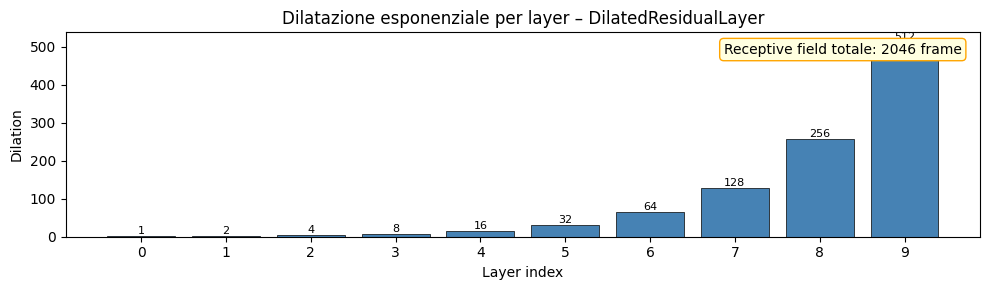

In [81]:
# Visualizza la crescita della dilatazione per stage
fig, ax = plt.subplots(figsize=(10, 3))
layers   = list(range(N_LAYERS))
dilations = [2**i for i in layers]
ax.bar(layers, dilations, color="steelblue", edgecolor="k", linewidth=0.5)
ax.set_xlabel("Layer index")
ax.set_ylabel("Dilation")
ax.set_title("Dilatazione esponenziale per layer – DilatedResidualLayer")
ax.set_xticks(layers)
for i, d in enumerate(dilations):
    ax.text(i, d + 5, str(d), ha="center", fontsize=8)
rf_total = 2 * sum(dilations)
ax.text(0.98, 0.95, f"Receptive field totale: {rf_total} frame",
        transform=ax.transAxes, ha="right", va="top",
        bbox=dict(boxstyle="round", fc="lightyellow", ec="orange"))
plt.tight_layout()
plt.show()

## 3. Caricamento dei pesi dal checkpoint

Il checkpoint è salvato da PyTorch Lightning (`TemporalSegmentationModule`). Usiamo `load_from_checkpoint` che ricostruisce automaticamente il modulo con i pesi salvati.

In [82]:
from src.training.module import TemporalSegmentationModule

pl_module = TemporalSegmentationModule.load_from_checkpoint(
    checkpoint_path = str(CHECKPOINT_PATH),
    model           = MSTCNModel(
        feat_dim    = FEAT_DIM,
        num_classes = NUM_CLASSES,
        hidden      = HIDDEN,
        n_stages    = N_STAGES,
        n_layers    = N_LAYERS,
        dropout     = DROPOUT,
    ),
    map_location = DEVICE,
)

model = pl_module.model.to(DEVICE)
model.eval()

ckpt_meta = torch.load(CHECKPOINT_PATH, map_location="cpu")
print("Checkpoint caricato con successo!")
print(f"Epoch salvata : {ckpt_meta.get('epoch', 'N/A')}")
print(f"Hparams       : {pl_module.hparams}")

Checkpoint caricato con successo!
Epoch salvata : 99
Hparams       : "bg_weight":       0.05
"boundary_weight": 0.3
"label_smoothing": 0.1
"lr":              0.0004
"num_classes":     106
"smooth_weight":   0.2
"weight_decay":    0.005


## 4. Caricamento di una clip dal dataset

Carichiamo una clip dal test split usando `EGTEADataset` in modalità **sliding window**.

In [ ]:
from src.datasets.dataset import EGTEADataset, load_split, load_action_labels

test_split_file = ANNOTATION_DIR / f"test_split{SPLIT}.txt"
if not test_split_file.exists():
    test_split_file = ANNOTATION_DIR / f"train_split{SPLIT}.txt"
    print(f"Test split non trovato, uso: {test_split_file.name}")
else:
    print(f"Test split: {test_split_file.name}")

test_clips        = load_split(str(test_split_file))
ann_path          = ANNOTATION_DIR / "raw_annotations" / "action_labels.csv"
dense_annotations = load_action_labels(str(ann_path))

def actual_fg_classes(clip):
    fs, fe = clip["frame_start"], clip["frame_end"]
    T  = fe - fs + 1
    gt = np.zeros(T, dtype=int)
    for (ann_start, ann_end, action_id) in dense_annotations.get(clip["video_session"], []):
        o_s = max(ann_start, fs) - fs
        o_e = min(ann_end,   fe) - fs
        if 0 <= o_s <= o_e < T:
            gt[o_s : o_e + 1] = action_id
    fg_cls   = set(gt[gt != 0].tolist())
    fg_ratio = (gt != 0).mean()
    return len(fg_cls), fg_ratio

min_frames = 256
candidates = []
for i, c in enumerate(test_clips):
    if c["frame_end"] - c["frame_start"] + 1 < min_frames:
        continue
    n_cls, fg_r = actual_fg_classes(c)
    if n_cls >= 2:
        candidates.append((i, c, n_cls, fg_r))

candidates.sort(key=lambda x: (x[2], x[3]), reverse=True)

top3 = candidates[:3]
print(f"Clip valide (GT verificato): {len(candidates)}")
print(f"\nTop 3:")
for rank, (idx, c, n_cls, fg_r) in enumerate(top3, 1):
    dur = c["frame_end"] - c["frame_start"] + 1
    print(f"  #{rank} {c['clip_prefix'][:52]}")
    print(f"      dur={dur}f  fg_classes={n_cls}  fg_ratio={fg_r:.2f}")

selected_clip = top3[0][1]
n_frames      = selected_clip["frame_end"] - selected_clip["frame_start"] + 1

In [ ]:
def build_window_starts(T, seq_len, stride):
    if T <= seq_len:
        return [0]
    ws = list(range(0, T - seq_len + 1, stride))
    last = T - seq_len
    if last % stride != 0:
        ws.append(last)
    return ws

clips_data = []
for rank, (_, clip, n_cls, fg_r) in enumerate(top3, 1):
    n_f = clip["frame_end"] - clip["frame_start"] + 1
    ds  = EGTEADataset(
        features_dir   = str(FEATURES_DIR),
        annotation_dir = str(ANNOTATION_DIR),
        split_file     = test_split_file.name,
        clips          = [clip],
        seq_len        = SEQ_LEN,
        feat_dim       = FEAT_DIM,
        sliding_window = True,
        stride         = STRIDE,
    )
    n_w    = len(ds)
    feats  = [ds[i][0] for i in range(n_w)]
    labels = [ds[i][1] for i in range(n_w)]
    clips_data.append({
        "rank": rank, "clip": clip, "n_frames": n_f,
        "n_windows": n_w,
        "window_starts": build_window_starts(n_f, SEQ_LEN, STRIDE),
        "features_batch": torch.stack(feats).to(DEVICE),
        "labels_batch":   torch.stack(labels).to(DEVICE),
    })
    print(f"Clip #{rank}: {n_f} frame  →  {n_w} finestre  ({n_cls} classi FG)")

features_batch = clips_data[0]["features_batch"]
labels_batch   = clips_data[0]["labels_batch"]
n_windows      = clips_data[0]["n_windows"]
T_clip         = clips_data[0]["n_frames"]
window_starts  = clips_data[0]["window_starts"]

## 5. Preprocessing: Sliding Window

La clip viene suddivisa in finestre di `seq_len=128` frame con `stride=64` (overlap del 50%). Ogni frame (tranne i bordi) contribuisce a **2 finestre** diverse.

Clip: 469 frame  →  7 finestre


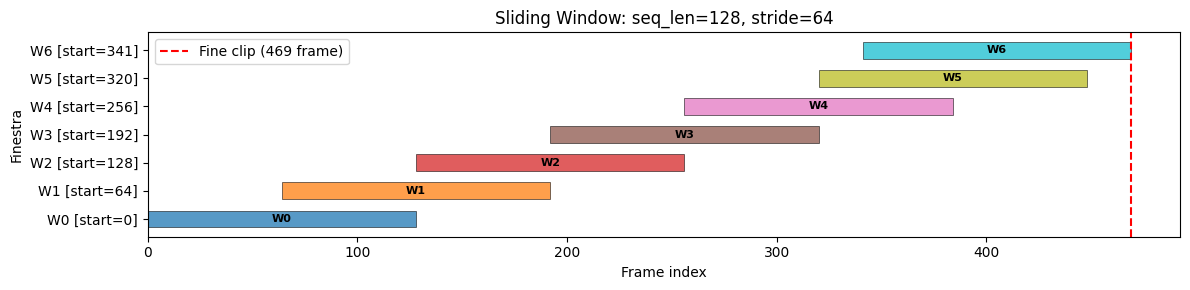

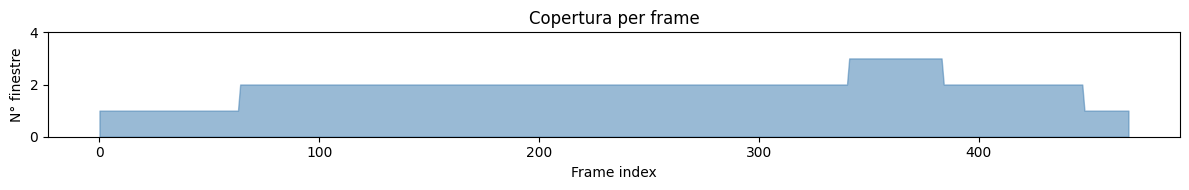

In [85]:
# Ricostruisce le posizioni di inizio finestra (come _build_sliding_samples)
T_clip = n_frames
window_starts = []
if T_clip <= SEQ_LEN:
    window_starts = [0]
else:
    for s in range(0, T_clip - SEQ_LEN + 1, STRIDE):
        window_starts.append(s)
    last = T_clip - SEQ_LEN
    if (last % STRIDE) != 0:
        window_starts.append(last)

print(f"Clip: {T_clip} frame  →  {len(window_starts)} finestre")

fig, ax = plt.subplots(figsize=(12, max(3, len(window_starts) * 0.4)))
cmap = plt.cm.tab10(np.linspace(0, 1, len(window_starts)))
for i, start in enumerate(window_starts):
    ax.barh(i, SEQ_LEN, left=start, height=0.6,
            color=cmap[i], alpha=0.75, edgecolor="k", linewidth=0.5)
    ax.text(start + SEQ_LEN/2, i, f"W{i}", ha="center", va="center", fontsize=8, fontweight="bold")
ax.axvline(T_clip, color="red", linestyle="--", linewidth=1.5, label=f"Fine clip ({T_clip} frame)")
ax.set_xlabel("Frame index")
ax.set_ylabel("Finestra")
ax.set_title(f"Sliding Window: seq_len={SEQ_LEN}, stride={STRIDE}")
ax.set_yticks(range(len(window_starts)))
ax.set_yticklabels([f"W{i} [start={s}]" for i, s in enumerate(window_starts)])
ax.legend()
plt.tight_layout()
plt.show()

# Copertura: quante finestre coprono ogni frame
coverage = np.zeros(T_clip, dtype=int)
for s in window_starts:
    coverage[s : min(s + SEQ_LEN, T_clip)] += 1

fig, ax = plt.subplots(figsize=(12, 2))
ax.fill_between(range(T_clip), coverage, alpha=0.55, color="steelblue")
ax.set_xlabel("Frame index")
ax.set_ylabel("N° finestre")
ax.set_title("Copertura per frame")
ax.set_ylim(0, max(coverage) + 1)
plt.tight_layout()
plt.show()

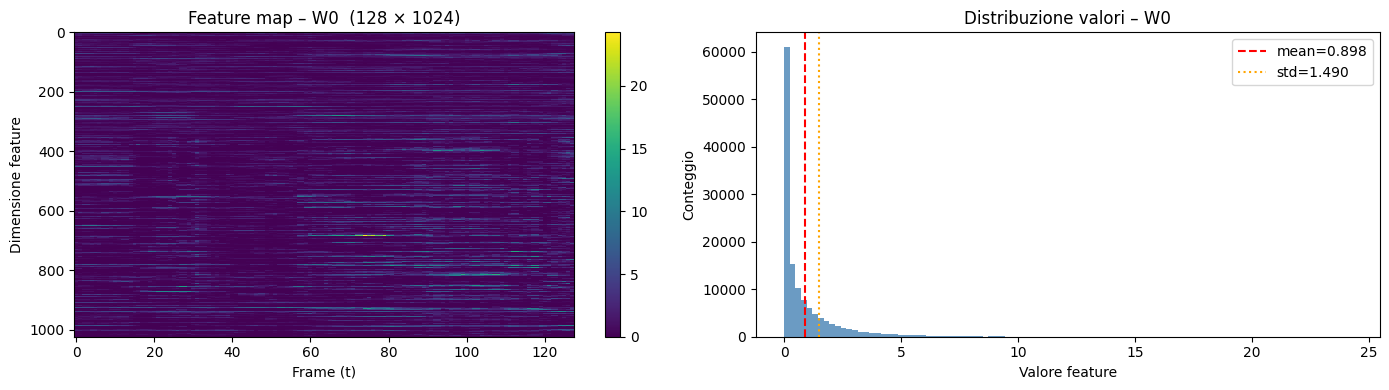

Feature stats – min=0.0000  max=24.2700  mean=0.8976  std=1.4902


In [86]:
# Visualizza le feature della prima finestra
feat0 = features_list[0].numpy()  # (seq_len, feat_dim)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
im = axes[0].imshow(feat0.T, aspect="auto", cmap="viridis", interpolation="nearest")
axes[0].set_xlabel("Frame (t)")
axes[0].set_ylabel("Dimensione feature")
axes[0].set_title(f"Feature map – W0  ({SEQ_LEN} × {FEAT_DIM})")
plt.colorbar(im, ax=axes[0])

axes[1].hist(feat0.flatten(), bins=100, color="steelblue", edgecolor="none", alpha=0.8)
axes[1].set_xlabel("Valore feature")
axes[1].set_ylabel("Conteggio")
axes[1].set_title("Distribuzione valori – W0")
axes[1].axvline(feat0.mean(), color="red",    linestyle="--", label=f"mean={feat0.mean():.3f}")
axes[1].axvline(feat0.std(),  color="orange", linestyle=":",  label=f"std={feat0.std():.3f}")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Feature stats – min={feat0.min():.4f}  max={feat0.max():.4f}  mean={feat0.mean():.4f}  std={feat0.std():.4f}")

## 6. Forward pass – stage per stage

Eseguiamo il forward di **MS-TCN++** step by step, visualizzando come i logits vengono raffinati in ciascuno dei 4 stage.

In [ ]:
model.eval()
with torch.no_grad():
    x_single = features_batch[0:1]          # (1, seq_len, feat_dim)
    x_perm   = x_single.permute(0, 2, 1)   # (1, feat_dim, T)
    print(f"Input permutato: {tuple(x_perm.shape)}  [B, feat_dim={FEAT_DIM}, T]")

    stage_logits_list = []
    stage_probs_list  = []

    # Stage 1: legge le feature DINOv3 (768-dim)
    out = model.stages[0](x_perm)              # (1, num_classes, T)
    logits_s1 = out.permute(0, 2, 1)           # (1, T, num_classes)
    stage_logits_list.append(logits_s1)
    stage_probs_list.append(F.softmax(logits_s1, dim=-1))
    print(f"Stage 1 – input: {FEAT_DIM}-dim features  →  output: {tuple(logits_s1.shape)}")

    # Stage 2-4: ricevono softmax dello stage precedente (106-dim)
    for s_idx, stage in enumerate(model.stages[1:], start=2):
        out   = stage(F.softmax(out, dim=1))   # (1, num_classes, T)
        logits_s = out.permute(0, 2, 1)
        stage_logits_list.append(logits_s)
        stage_probs_list.append(F.softmax(logits_s, dim=-1))
        print(f"Stage {s_idx} – input: 106-dim softmax   →  output: {tuple(logits_s.shape)}")

print("\nForward pass completato.")

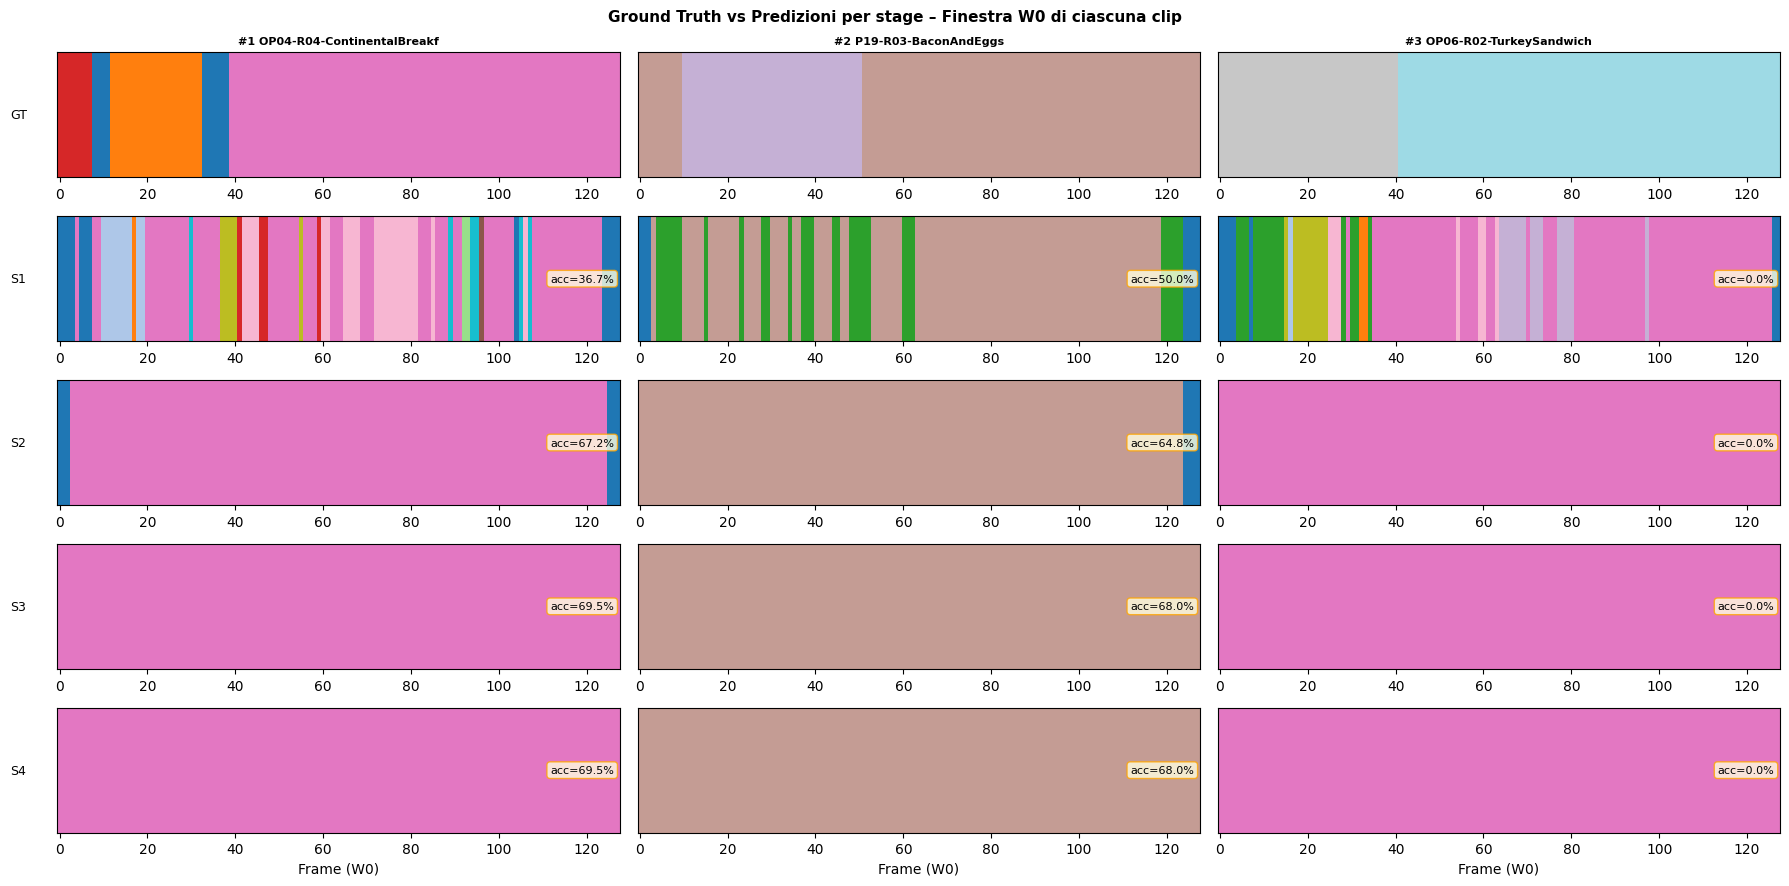

In [88]:
# GT vs Predizioni per stage – W0 di ciascuna delle 3 clip
fig, axes = plt.subplots(N_STAGES + 1, 3, figsize=(18, 9), sharex=False)

model.eval()
for col, cd in enumerate(clips_data):
    gt_w = cd["labels_batch"][0].cpu().numpy()   # GT della finestra W0

    # Forward pass stage per stage per questa clip
    with torch.no_grad():
        x_p = cd["features_batch"][0:1].permute(0, 2, 1)   # (1, feat_dim, T)
        out = model.stages[0](x_p)
        stage_preds = [out.permute(0, 2, 1)[0].argmax(-1).cpu().numpy()]
        for stage in model.stages[1:]:
            out = stage(F.softmax(out, dim=1))
            stage_preds.append(out.permute(0, 2, 1)[0].argmax(-1).cpu().numpy())

    # Riga GT
    ax = axes[0, col]
    ax.imshow(gt_w[np.newaxis, :], aspect="auto", cmap="tab20",
              vmin=0, vmax=NUM_CLASSES - 1, interpolation="nearest")
    ax.set_yticks([])
    ax.set_title(f"#{cd['rank']} {cd['clip']['video_session'][:26]}", fontsize=8, fontweight="bold")
    if col == 0:
        ax.set_ylabel("GT", rotation=0, labelpad=28, va="center", fontsize=9)

    # Righe stage
    for s_idx, preds_s in enumerate(stage_preds):
        ax = axes[s_idx + 1, col]
        ax.imshow(preds_s[np.newaxis, :], aspect="auto", cmap="tab20",
                  vmin=0, vmax=NUM_CLASSES - 1, interpolation="nearest")
        ax.set_yticks([])
        acc = (preds_s == gt_w).mean() * 100
        ax.text(0.99, 0.5, f"acc={acc:.1f}%", transform=ax.transAxes,
                ha="right", va="center", fontsize=8,
                bbox=dict(boxstyle="round", fc="lightyellow", ec="orange", alpha=0.8))
        if col == 0:
            ax.set_ylabel(f"S{s_idx+1}", rotation=0, labelpad=28, va="center", fontsize=9)

    axes[-1, col].set_xlabel("Frame (W0)")

plt.suptitle("Ground Truth vs Predizioni per stage – Finestra W0 di ciascuna clip",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

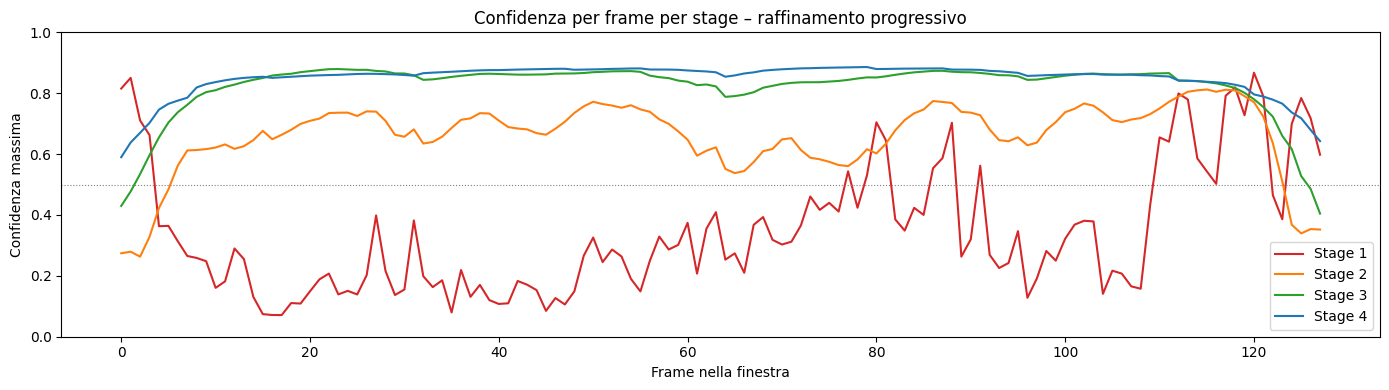

In [89]:
# Confidenza massima (max softmax prob) per stage
colors_s = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]
fig, ax = plt.subplots(figsize=(14, 4))
for s_idx, probs_s in enumerate(stage_probs_list):
    max_conf = probs_s[0].max(dim=-1).values.cpu().numpy()
    ax.plot(max_conf, label=f"Stage {s_idx+1}", color=colors_s[s_idx], linewidth=1.5)
ax.set_xlabel("Frame nella finestra")
ax.set_ylabel("Confidenza massima")
ax.set_title("Confidenza per frame per stage – raffinamento progressivo")
ax.legend()
ax.set_ylim(0, 1)
ax.axhline(0.5, color="gray", linestyle=":", linewidth=0.8)
plt.tight_layout()
plt.show()

Classi in W0: [(0, 'Inspect/Read recipe'), (12, 'Put condiment_container'), (36, 'Close condiment_container'), (66, 'Mix mixture,eating_utensil')]


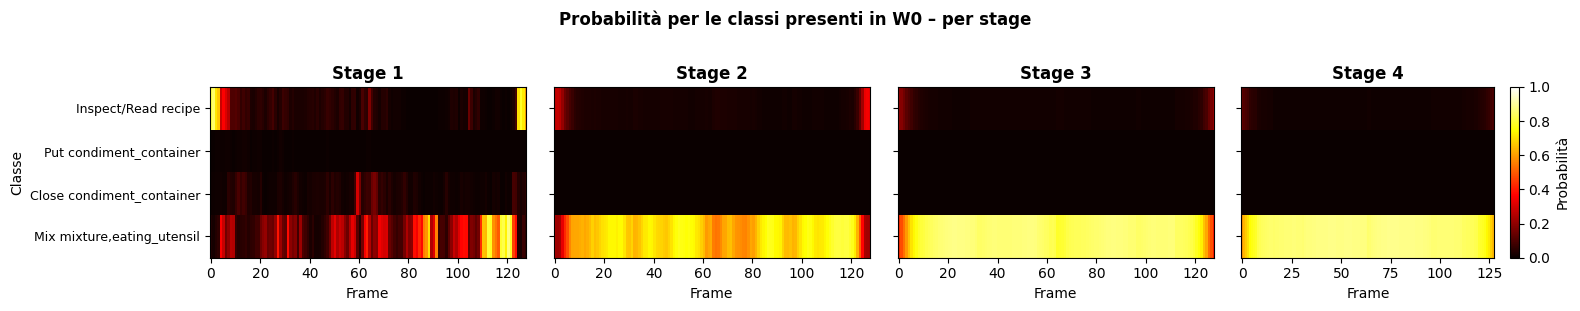

In [90]:
# Heatmap probabilità – solo le classi presenti nel GT della finestra W0
gt_w0   = labels_batch[0].cpu().numpy()
top_ids = sorted(set(gt_w0.tolist()))                      # classi reali in W0
top_lbl = [id_to_label.get(c, str(c)) for c in top_ids]
n_top   = len(top_ids)

print(f"Classi in W0: {[(i, id_to_label.get(i,'?')) for i in top_ids]}")

fig, axes = plt.subplots(1, N_STAGES, figsize=(16, max(3, n_top * 0.55)), sharey=True)
for s_idx, probs_s in enumerate(stage_probs_list):
    probs_np = probs_s[0, :, top_ids].cpu().numpy().T   # (n_top, T)
    im = axes[s_idx].imshow(probs_np, aspect="auto", cmap="hot",
                            vmin=0, vmax=1, interpolation="nearest")
    axes[s_idx].set_title(f"Stage {s_idx + 1}", fontweight="bold")
    axes[s_idx].set_xlabel("Frame")
    if s_idx == 0:
        axes[s_idx].set_ylabel("Classe")
        axes[s_idx].set_yticks(range(n_top))
        axes[s_idx].set_yticklabels(top_lbl, fontsize=9)
plt.colorbar(im, ax=axes[-1], label="Probabilità")
plt.suptitle("Probabilità per le classi presenti in W0 – per stage", y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Forward pass completo sull'intera clip + aggregazione

Eseguiamo il forward su tutte le finestre e **mediamo i logits** nelle zone di overlap per ottenere una predizione coerente sull'intera clip.

In [91]:
model.eval()
with torch.no_grad():
    for cd in clips_data:
        logits_wins = []
        for i in range(cd["n_windows"]):
            lw = model(cd["features_batch"][i:i+1])
            logits_wins.append(lw[0].cpu())

        T   = cd["n_frames"]
        agg = torch.zeros(T, NUM_CLASSES)
        cnt = torch.zeros(T)
        for w_i, start in enumerate(cd["window_starts"]):
            end    = min(start + SEQ_LEN, T)
            length = end - start
            agg[start:end] += logits_wins[w_i][:length]
            cnt[start:end] += 1
        agg /= cnt.unsqueeze(-1).clamp(min=1)

        cd["predictions"] = agg.argmax(dim=-1).numpy()
        cd["confidence"]  = F.softmax(agg, dim=-1).max(dim=-1).values.numpy()
        print(f"Clip #{cd['rank']}: shape={cd['predictions'].shape}  conf_media={cd['confidence'].mean():.3f}")

# backward compat
predictions   = clips_data[0]["predictions"]
confidence    = clips_data[0]["confidence"]

Clip #1: shape=(469,)  conf_media=0.776
Clip #2: shape=(579,)  conf_media=0.630
Clip #3: shape=(492,)  conf_media=0.653


In [92]:
for cd in clips_data:
    clip = cd["clip"]
    fs, fe, vs = clip["frame_start"], clip["frame_end"], clip["video_session"]
    T    = cd["n_frames"]
    gt   = np.zeros(T, dtype=int)
    for (ann_start, ann_end, action_id) in dense_annotations.get(vs, []):
        o_s = max(ann_start, fs) - fs
        o_e = min(ann_end,   fe) - fs
        if 0 <= o_s <= o_e < T:
            gt[o_s : o_e + 1] = action_id

    preds  = cd["predictions"]
    fa     = (preds == gt).mean() * 100
    fmask  = gt != 0
    fg_a   = (preds[fmask] == gt[fmask]).mean() * 100 if fmask.any() else 0.0

    cd["gt_full"]   = gt
    cd["frame_acc"] = fa
    cd["fg_acc"]    = fg_a

    gt_cls = [c for c in np.unique(gt) if c != 0]
    print(f"Clip #{cd['rank']}: FrmAcc={fa:.1f}%  FGAcc={fg_a:.1f}%")
    print(f"  Classi GT: {[id_to_label.get(c, c) for c in gt_cls]}")

# backward compat
gt_full   = clips_data[0]["gt_full"]
frame_acc = clips_data[0]["frame_acc"]
fg_acc    = clips_data[0]["fg_acc"]

Clip #1: FrmAcc=83.2%  FGAcc=85.2%
  Classi GT: ['Put eating_utensil', 'Put condiment_container', 'Take bowl', 'Close condiment_container', 'Mix mixture,eating_utensil']
Clip #2: FrmAcc=48.2%  FGAcc=48.2%
  Classi GT: ['Take sponge', 'Put sponge', 'Wash pan']
Clip #3: FrmAcc=0.0%  FGAcc=0.0%
  Classi GT: ['Put cheese', 'Take cheese', 'Open cheese_container']


## 8. Metriche: Edit Score e F1@k

In [93]:
from src.training.module import edit_score, f1_at_k, get_segments, boundary_f1

print("─" * 74)
print(f"  {'Clip':<20} {'FrmAcc':>7} {'FGAcc':>7} {'Edit':>6} {'F1@10':>6} {'F1@25':>6} {'F1@50':>6} {'BF1':>6}")
print("─" * 74)

for cd in clips_data:
    p = torch.tensor(cd["predictions"])
    g = torch.tensor(cd["gt_full"])
    m = dict(
        es  = edit_score(p, g),
        f10 = f1_at_k(p, g, 0.10),
        f25 = f1_at_k(p, g, 0.25),
        f50 = f1_at_k(p, g, 0.50),
        bf1 = boundary_f1(p, g),
        n_gt   = len(get_segments(g)),
        n_pred = len(get_segments(p)),
    )
    cd["metrics"] = m
    name = cd["clip"]["clip_prefix"][:20]
    print(f"  {name:<20} {cd['frame_acc']:>6.1f}% {cd['fg_acc']:>6.1f}%"
          f" {m['es']:>6.3f} {m['f10']:>6.3f} {m['f25']:>6.3f} {m['f50']:>6.3f} {m['bf1']:>6.3f}")
    print(f"  {'':20}   segmenti GT={m['n_gt']}  predetti={m['n_pred']}")

print("─" * 74)

# backward compat
es = clips_data[0]["metrics"]["es"];  f25 = clips_data[0]["metrics"]["f25"]
f10 = clips_data[0]["metrics"]["f10"]; f50 = clips_data[0]["metrics"]["f50"]
bf1 = clips_data[0]["metrics"]["bf1"]

──────────────────────────────────────────────────────────────────────────
  Clip                  FrmAcc   FGAcc   Edit  F1@10  F1@25  F1@50    BF1
──────────────────────────────────────────────────────────────────────────
  OP04-R04-Continental   83.2%   85.2%  0.200  0.333  0.333  0.333  0.000
                         segmenti GT=5  predetti=1
  P19-R03-BaconAndEggs   48.2%   48.2%  0.200  0.222  0.222  0.222  0.000
                         segmenti GT=5  predetti=4
  OP06-R02-TurkeySandw    0.0%    0.0%  0.000  0.000  0.000  0.000  0.000
                         segmenti GT=3  predetti=5
──────────────────────────────────────────────────────────────────────────


## 9. Visualizzazione finale: GT vs Predizioni

Timeline completa della clip con ground truth, predizioni, errori e confidenza.

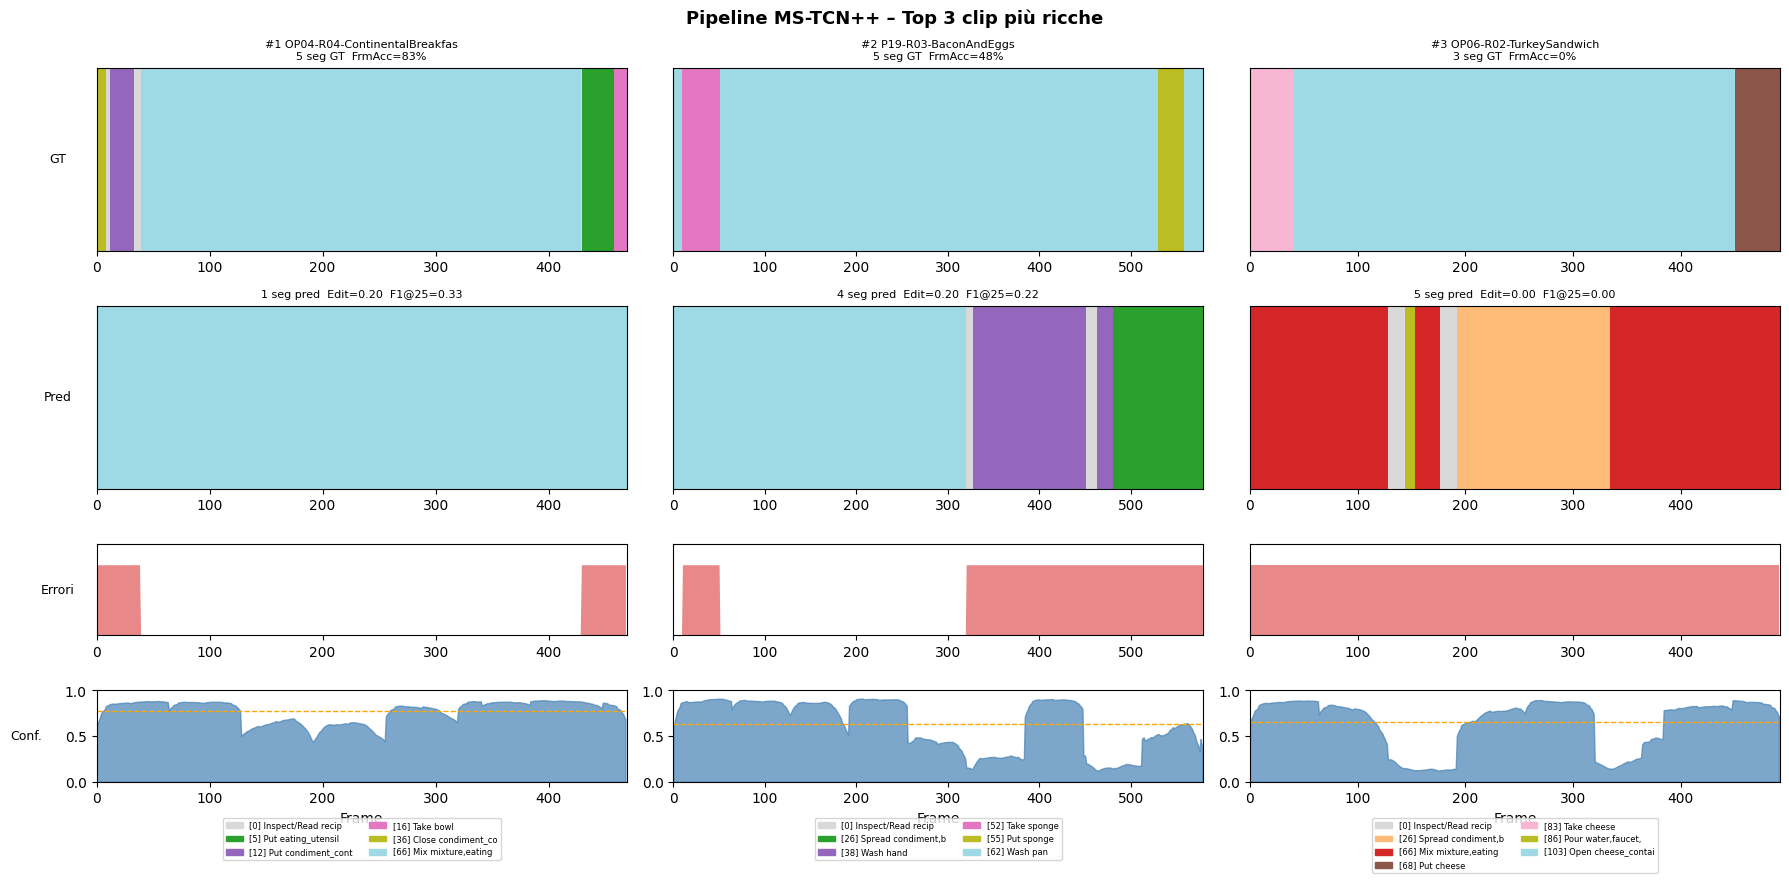

Plot salvato in mstcn_pipeline_output.png


In [94]:
def clip_colormap(gt, preds):
    all_cls = sorted(set(np.unique(gt).tolist() + np.unique(preds).tolist()))
    cmap    = plt.cm.get_cmap("tab20", max(len(all_cls), 2))
    cc = {c: cmap(i) for i, c in enumerate(all_cls)}
    cc[0] = (0.85, 0.85, 0.85, 1.0)
    return cc, all_cls

fig, axes = plt.subplots(4, 3, figsize=(18, 9),
                         gridspec_kw={"height_ratios": [1, 1, 0.5, 0.5]})

for col, cd in enumerate(clips_data):
    gt    = cd["gt_full"]
    preds = cd["predictions"]
    conf  = cd["confidence"]
    T     = cd["n_frames"]
    m     = cd["metrics"]

    cc, all_cls = clip_colormap(gt, preds)
    gt_col   = np.array([cc[int(s)] for s in gt])
    pred_col = np.array([cc[int(s)] for s in preds])

    # Riga 0 – Ground Truth
    ax = axes[0, col]
    for t in range(T):
        ax.axvspan(t, t + 1, color=gt_col[t], linewidth=0)
    ax.set_xlim(0, T); ax.set_yticks([])
    session = cd["clip"]["video_session"][:28]
    ax.set_title(f"#{cd['rank']} {session}\n{m['n_gt']} seg GT  FrmAcc={cd['frame_acc']:.0f}%", fontsize=8)
    if col == 0: ax.set_ylabel("GT", rotation=0, labelpad=28, va="center", fontsize=9)

    # Riga 1 – Predizioni
    ax = axes[1, col]
    for t in range(T):
        ax.axvspan(t, t + 1, color=pred_col[t], linewidth=0)
    ax.set_xlim(0, T); ax.set_yticks([])
    ax.set_title(f"{m['n_pred']} seg pred  Edit={m['es']:.2f}  F1@25={m['f25']:.2f}", fontsize=8)
    if col == 0: ax.set_ylabel("Pred", rotation=0, labelpad=28, va="center", fontsize=9)

    # Riga 2 – Errori
    ax = axes[2, col]
    errors = (preds != gt).astype(float)
    ax.fill_between(range(T), errors, color="#d62728", alpha=0.55, linewidth=0)
    ax.set_xlim(0, T); ax.set_ylim(0, 1.3); ax.set_yticks([])
    if col == 0: ax.set_ylabel("Errori", rotation=0, labelpad=28, va="center", fontsize=9)

    # Riga 3 – Confidenza
    ax = axes[3, col]
    ax.fill_between(range(T), conf, alpha=0.7, color="steelblue")
    ax.axhline(conf.mean(), color="orange", linestyle="--", linewidth=1,
               label=f"μ={conf.mean():.2f}")
    ax.set_xlim(0, T); ax.set_ylim(0, 1)
    ax.set_xlabel("Frame"); ax.legend(fontsize=7, loc="lower right")
    if col == 0: ax.set_ylabel("Conf.", rotation=0, labelpad=28, va="center", fontsize=9)

    # Legenda classi
    handles = [mpatches.Patch(color=cc[c], label=f"[{c}] {id_to_label.get(c,'?')[:18]}")
               for c in all_cls]
    axes[3, col].legend(handles=handles, loc="upper center",
                        bbox_to_anchor=(0.5, -0.35), ncol=2, fontsize=6, framealpha=0.8)

plt.suptitle("Pipeline MS-TCN++ – Top 3 clip più ricche", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("mstcn_pipeline_output.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot salvato in mstcn_pipeline_output.png")

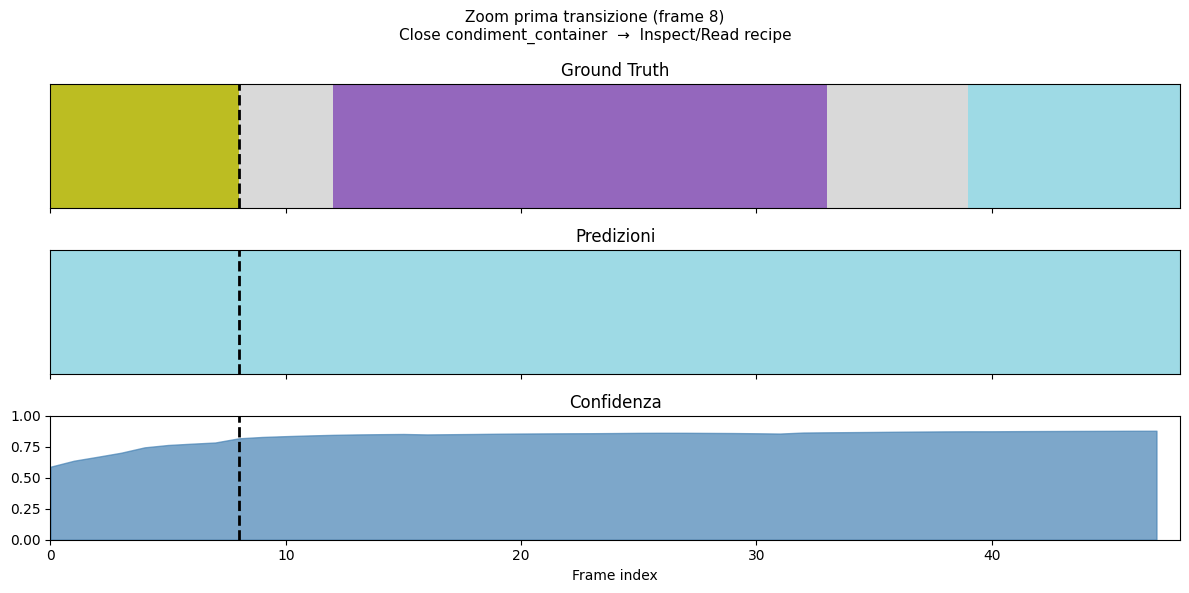

In [95]:
# Zoom sulla prima transizione GT
transitions = [t for t in range(1, T_clip) if gt_full[t] != gt_full[t - 1]]

if transitions:
    tc      = transitions[0]
    z_start = max(0,      tc - 40)
    z_end   = min(T_clip, tc + 40)
    z_range = range(z_start, z_end)

    fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
    for t in z_range:
        axes[0].axvspan(t, t + 1, color=gt_colors[t],   linewidth=0)
        axes[1].axvspan(t, t + 1, color=pred_colors[t], linewidth=0)
    for ax in axes[:2]:
        ax.axvline(tc, color="k", linestyle="--", linewidth=2)
        ax.set_xlim(z_start, z_end); ax.set_yticks([])
    axes[0].set_title("Ground Truth")
    axes[1].set_title("Predizioni")

    axes[2].fill_between(z_range, confidence[z_start:z_end], alpha=0.7, color="steelblue")
    axes[2].axvline(tc, color="k", linestyle="--", linewidth=2)
    axes[2].set_xlim(z_start, z_end); axes[2].set_ylim(0, 1)
    axes[2].set_xlabel("Frame index")
    axes[2].set_title("Confidenza")

    plt.suptitle(
        f"Zoom prima transizione (frame {tc})\n"
        f"{id_to_label.get(gt_full[tc-1], '?')}  →  {id_to_label.get(gt_full[tc], '?')}",
        fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("Nessuna transizione trovata nella clip.")

## 10. Riepilogo della pipeline

```
D:/egtea/dinov3_features/{video_session}.npy   (T, 768)  float32
    ↓
[NpyReader.get_clip()]  →  features  (T, 768)  float32
    ↓
[EGTEADataset sliding window]  →  finestre  (n_w, 128, 768)
    ↓
[MSTCNModel – Stage 1]  features (768) → logits (106)
[MSTCNModel – Stage 2]  softmax  (106) → logits (106)
[MSTCNModel – Stage 3]  softmax  (106) → logits (106)
[MSTCNModel – Stage 4]  softmax  (106) → logits (106)  ← output finale
    ↓
[aggregazione media overlap]  →  logits  (T, 106)
    ↓
[argmax]  →  classe per frame  (T,)
    ↓
[metriche]  Edit Score / F1@k / Boundary F1
```

In [96]:
print("═" * 76)
print(f"  RIEPILOGO PIPELINE MS-TCN++  –  Top 3 clip")
print("═" * 76)
print(f"  {'Clip':<32} {'Frames':>6} {'FrmAcc':>7} {'Edit':>6} {'F1@10':>6} {'F1@25':>6} {'BF1':>6}")
print("─" * 76)
for cd in clips_data:
    m = cd["metrics"]
    print(f"  {cd['clip']['clip_prefix'][:32]:<32} {cd['n_frames']:>6}"
          f" {cd['frame_acc']:>6.1f}% {m['es']:>6.3f} {m['f10']:>6.3f} {m['f25']:>6.3f} {m['bf1']:>6.3f}")
print("═" * 76)

════════════════════════════════════════════════════════════════════════════
  RIEPILOGO PIPELINE MS-TCN++  –  Top 3 clip
════════════════════════════════════════════════════════════════════════════
  Clip                             Frames  FrmAcc   Edit  F1@10  F1@25    BF1
────────────────────────────────────────────────────────────────────────────
  OP04-R04-ContinentalBreakfast-14    469   83.2%  0.200  0.333  0.333  0.000
  P19-R03-BaconAndEggs-1438975-145    579   48.2%  0.200  0.222  0.222  0.000
  OP06-R02-TurkeySandwich-180260-1    492    0.0%  0.000  0.000  0.000  0.000
════════════════════════════════════════════════════════════════════════════
